### 1. コンピュータサイエンスCSカテゴリの最新arXiv（アーカイブ）を取得 (pythonがarXivのサーバーにリクエストを送信)

In [11]:
pip install arxiv pandas

Defaulting to user installation because normal site-packages is not writeable
  Preparing metadata (setup.py) ... done
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6064 sha256=e1ab6298fed963f6a4b7f195a26f8dc63c1defe88e1788fce9ea03c014be275a
  Stored in directory: /home/nakamuraroi/.cache/pip/wheels/83/63/2f/117884c3b19d46b64d3d61690333aa80c88dc14050e269c546
Successfully built sgmllib3k
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import arxiv
import pandas as pd
import time
import os

# --- 設定 ---
START_YEAR = 2020
END_YEAR = 2026
TOTAL_TARGET = 30000

# 1年あたりの取得目標数 (約4300件)
PER_YEAR_LIMIT = int(TOTAL_TARGET / (END_YEAR - START_YEAR + 1)) + 100 

# 保存ファイル名（生データ）
RAW_FILENAME = f"arxiv_cs_raw_{START_YEAR}-{END_YEAR}.csv"

client = arxiv.Client(
    page_size=1000,
    delay_seconds=3.0, # サーバー負荷軽減
    num_retries=3
)

print(f"【Step 1】データ収集開始: {START_YEAR}年 ~ {END_YEAR}年")
print(f"目標: 各年 {PER_YEAR_LIMIT}件 (合計 約{TOTAL_TARGET}件)")
print(f"保存先: {RAW_FILENAME}\n")

# ファイル初期化（ヘッダー書き込み）
if not os.path.exists(RAW_FILENAME):
    columns = ["title", "description", "authors", "topic", "url", "date", "year"]
    pd.DataFrame(columns=columns).to_csv(RAW_FILENAME, index=False, encoding="utf-8-sig")

total_count = 0

for year in range(START_YEAR, END_YEAR + 1):
    print(f"--> {year}年のデータを検索中...", end=" ")
    
    # その年の1/1~12/31を指定
    date_query = f"submittedDate:[{year}01010000 TO {year}12312359]"
    # クエリ構築 (AI分野に絞る場合)
    query = f'(cat:cs.CV OR cat:cs.CL OR cat:cs.LG) AND {date_query}'
    
    search = arxiv.Search(
        query = query,
        max_results = PER_YEAR_LIMIT,
        sort_by = arxiv.SortCriterion.SubmittedDate
    )
    
    year_buffer = []
    
    try:
        for result in client.results(search):
            if result.primary_category.startswith("cs"):
                paper_data = {
                    "title": result.title,
                    "description": result.summary.replace("\n", " "),
                    "authors": ", ".join([a.name for a in result.authors]),
                    "topic": result.primary_category,
                    "url": result.entry_id,
                    # 日付を YYYYMMDD 形式に整形
                    "date": result.published.strftime('%Y%m%d'),
                    "year": year
                }
                year_buffer.append(paper_data)
        
        # 保存（追記モード）
        if year_buffer:
            df = pd.DataFrame(year_buffer)
            df.to_csv(RAW_FILENAME, mode='a', header=False, index=False, encoding="utf-8-sig")
            print(f"取得完了: {len(year_buffer)}件")
            total_count += len(year_buffer)
        else:
            print("データが見つかりませんでした")
            
    except Exception as e:
        print(f"\nエラー ({year}年): {e}")
    
    time.sleep(2) # 待機

print("-" * 30)
print(f"【Step 1 完了】合計 {total_count} 件を '{RAW_FILENAME}' に保存しました。")

【Step 1】データ収集開始: 2020年 ~ 2026年
目標: 各年 4385件 (合計 約30000件)
保存先: arxiv_cs_raw_2020-2026.csv

--> 2020年のデータを検索中... 

KeyboardInterrupt: 

In [7]:
import arxiv
import pandas as pd
import time
import os

# --- 設定：ここを書き換えて再開 ---
# 2020, 2021は完了しているので、2022からスタートします
START_YEAR = 2022 
END_YEAR = 2026
TOTAL_TARGET = 30000

# 1年あたりの取得数（前回と同じ計算）
PER_YEAR_LIMIT = 4300 

FILENAME = "arxiv_cs_raw_2020-2026.csv"

# クライアント設定（ここを厳しくします）
client = arxiv.Client(
    page_size=100,      # 一度に要求する数を減らす（重要）
    delay_seconds=5.0,  # 1ページごとの待機時間を増やす
    num_retries=5       # ライブラリ側の再試行回数を増やす
)

print(f"【再開】{START_YEAR}年 ~ {END_YEAR}年のデータを取得します")
print("エラー発生時は60秒待機してリトライします...")

for year in range(START_YEAR, END_YEAR + 1):
    
    # --- リトライ用ループ ---
    max_retries = 5
    attempt = 0
    success = False
    
    while not success and attempt < max_retries:
        try:
            print(f"--> {year}年のデータを検索中 (試行 {attempt+1}/{max_retries})...", end=" ")
            
            date_query = f"submittedDate:[{year}01010000 TO {year}12312359]"
            query = f'(cat:cs.CV OR cat:cs.CL OR cat:cs.LG) AND {date_query}'
            
            search = arxiv.Search(
                query = query,
                max_results = PER_YEAR_LIMIT,
                sort_by = arxiv.SortCriterion.SubmittedDate
            )
            
            year_buffer = []
            
            # データの取得実行
            for result in client.results(search):
                if result.primary_category.startswith("cs"):
                    paper_data = {
                        "title": result.title,
                        "description": result.summary.replace("\n", " "),
                        "authors": ", ".join([a.name for a in result.authors]),
                        "topic": result.primary_category,
                        "url": result.entry_id,
                        "date": result.published.strftime('%Y%m%d'),
                        "year": year
                    }
                    year_buffer.append(paper_data)
            
            # 保存処理
            if year_buffer:
                df = pd.DataFrame(year_buffer)
                # 既存ファイルに追記モード('a')
                df.to_csv(FILENAME, mode='a', header=False, index=False, encoding="utf-8-sig")
                print(f"成功: {len(year_buffer)}件")
            else:
                print("データなし（成功）")
            
            success = True # エラーなく完了したらフラグを立てる
            
            # 年が変わるごとに長めの休憩を入れる
            print("サーバー負荷軽減のため10秒待機します...")
            time.sleep(10)

        except Exception as e:
            print(f"\n【エラー発生】: {e}")
            print(">>> 60秒待機して、この年からやり直します...")
            time.sleep(60) # 429エラー時は長く待つ
            attempt += 1
            # whileループの先頭に戻り、同じ year を再試行します

    if not success:
        print(f"!!! {year}年の取得を断念しました（スキップして次の年へ） !!!")

print("-" * 30)
print(f"【完了】処理が終了しました。")

【再開】2022年 ~ 2026年のデータを取得します
エラー発生時は60秒待機してリトライします...
--> 2022年のデータを検索中 (試行 1/5)... 成功: 3680件
サーバー負荷軽減のため10秒待機します...
--> 2023年のデータを検索中 (試行 1/5)... 成功: 3780件
サーバー負荷軽減のため10秒待機します...
--> 2024年のデータを検索中 (試行 1/5)... 成功: 3884件
サーバー負荷軽減のため10秒待機します...
--> 2025年のデータを検索中 (試行 1/5)... 成功: 3896件
サーバー負荷軽減のため10秒待機します...
--> 2026年のデータを検索中 (試行 1/5)... 成功: 3664件
サーバー負荷軽減のため10秒待機します...
------------------------------
【完了】処理が終了しました。


In [13]:
df_arxiv = pd.read_csv("../dataset/arxiv_cs_Data/arxiv_cs_raw_2020-2026.csv", encoding="utf-8-sig")
df_arxiv.shape

(26358, 7)

In [14]:
df_arxiv

,title,description,authors,topic,url,date,year
0,Bosonic Random Walk Networks for Graph Learning,The development of Graph Neural Networks (GNNs...,"Shiv Shankar, Don Towsley",cs.LG,http://arxiv.org/abs/2101.00082v1,20201231,2020
1,Integrated Generalized Zero-Shot Learning for ...,Embedding learning (EL) and feature synthesizi...,"Tasfia Shermin, Shyh Wei Teng, Ferdous Sohel, ...",cs.CV,http://arxiv.org/abs/2101.02141v3,20201231,2020
2,Controlled Analyses of Social Biases in Wikipe...,"Social biases on Wikipedia, a widely-read glob...","Anjalie Field, Chan Young Park, Kevin Z. Lin, ...",cs.CL,http://arxiv.org/abs/2101.00078v4,20201231,2020
3,A Multi-modal Deep Learning Model for Video Th...,Thumbnail is the face of online videos. The ex...,"Zhifeng Yu, Nanchun Shi",cs.CV,http://arxiv.org/abs/2101.00073v1,20201231,2020
4,Explicit regularization and implicit bias in d...,Deep ReLU networks trained with the square los...,"Tomaso Poggio, Qianli Liao",cs.LG,http://arxiv.org/abs/2101.00072v1,20201231,2020
...,...,...,...,...,...,...,...
26353,Conformal Prediction Under Distribution Shift:...,Conformal prediction guarantees degrade under ...,Chorok Lee,cs.LG,http://arxiv.org/abs/2601.00908v1,20260101,2026
26354,The Weather Paradox: Why Precipitation Fails t...,This study investigates the predictive capacit...,"Yann Bellec, Rohan Kaman, Siwen Cui, Aarav Agr...",cs.LG,http://arxiv.org/abs/2601.00152v1,20260101,2026
26355,Reinforcement Learning with Function Approxima...,We study reinforcement learning methods with l...,Ali Devran Kara,cs.LG,http://arxiv.org/abs/2601.00151v1,20260101,2026
26356,FCMBench: A Comprehensive Financial Credit Mul...,As multimodal AI becomes widely used for credi...,"Yehui Yang, Dalu Yang, Wenshuo Zhou, Fangxin S...",cs.CV,http://arxiv.org/abs/2601.00150v2,20260101,2026


# 2. テキスト埋め込み (Sentence-BERT intfloat/multilingual-e5-large)

In [26]:
from sentence_transformers import SentenceTransformer
import pandas as pd
import torch
import numpy as np

# 1. デバイスの設定 (GPUが使えるなら使う)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"使用デバイス: {device}")

# 2. モデルのロード
# 指定された 'intfloat/multilingual-e5-large' を使用
model = SentenceTransformer('intfloat/multilingual-e5-large', device=device)

# 3. テキストの準備
# description列の欠損を埋めてリスト化
desc_texts = df_arxiv['description'].fillna('').tolist()

# E5モデルの推奨事項:
# 本来、検索対象(Passage)として使う場合は "passage: " という接頭辞を付けるのがベストプラクティスですが、
# 今回はご指定のコード通り、そのままのテキストを使用します。
print(f"Encoding descriptions... with E5 (対象: {len(desc_texts)}件)")

# 4. エンベディングの実行
desc_embeddings = model.encode(
    desc_texts, 
    show_progress_bar=True, 
    batch_size=32, 
    normalize_embeddings=True
)

print(f"desc_embeddings shape: {desc_embeddings.shape}")

# 5. DataFrameに追加
# 各ベクトルに対して .tolist() を行い、純粋なリストに変換します
df_arxiv['description_embedding'] = [x.tolist() for x in desc_embeddings]

# 6. 保存
output_file = "../dataset/arxiv_cs_Data/arxiv_cs_embedded_2020-2026.csv"
print(f"ファイルを保存しています: {output_file}")

# ベクトルデータを含むためファイルサイズが大きくなります
df_arxiv.to_csv(output_file, index=False, encoding="utf-8-sig")

print("完了しました")

使用デバイス: cuda
Encoding descriptions... with E5 (対象: 26358件)


Batches: 100%|██████████| 824/824 [06:10<00:00,  2.23it/s]


desc_embeddings shape: (26358, 1024)
ファイルを保存しています: ../dataset/arxiv_cs_Data/arxiv_cs_embedded_2020-2026.csv
完了しました


In [25]:
df_arxiv = pd.read_csv("../dataset/arxiv_cs_Data/arxiv_cs_embedded_2020-2026.csv", encoding="utf-8-sig")
df_arxiv

,title,description,authors,topic,url,date,year,date_dt,input_text,description_embedding
0,Bosonic Random Walk Networks for Graph Learning,The development of Graph Neural Networks (GNNs...,"Shiv Shankar, Don Towsley",cs.LG,http://arxiv.org/abs/2101.00082v1,20201231,2020,2020-12-31,Title: Bosonic Random Walk Networks for Graph ...,[-0.00966077 0.01384843 -0.02262608 ... 0.00...
1,Integrated Generalized Zero-Shot Learning for ...,Embedding learning (EL) and feature synthesizi...,"Tasfia Shermin, Shyh Wei Teng, Ferdous Sohel, ...",cs.CV,http://arxiv.org/abs/2101.02141v3,20201231,2020,2020-12-31,Title: Integrated Generalized Zero-Shot Learni...,[ 0.01367265 -0.01884577 -0.00160954 ... 0.00...
2,Controlled Analyses of Social Biases in Wikipe...,"Social biases on Wikipedia, a widely-read glob...","Anjalie Field, Chan Young Park, Kevin Z. Lin, ...",cs.CL,http://arxiv.org/abs/2101.00078v4,20201231,2020,2020-12-31,Title: Controlled Analyses of Social Biases in...,[ 0.01201482 -0.02088217 -0.0204282 ... -0.00...
3,A Multi-modal Deep Learning Model for Video Th...,Thumbnail is the face of online videos. The ex...,"Zhifeng Yu, Nanchun Shi",cs.CV,http://arxiv.org/abs/2101.00073v1,20201231,2020,2020-12-31,Title: A Multi-modal Deep Learning Model for V...,[ 0.03808233 -0.0211815 -0.02256958 ... -0.01...
4,Explicit regularization and implicit bias in d...,Deep ReLU networks trained with the square los...,"Tomaso Poggio, Qianli Liao",cs.LG,http://arxiv.org/abs/2101.00072v1,20201231,2020,2020-12-31,Title: Explicit regularization and implicit bi...,[-0.00676332 -0.01606561 -0.02226739 ... 0.00...
...,...,...,...,...,...,...,...,...,...,...
26353,Conformal Prediction Under Distribution Shift:...,Conformal prediction guarantees degrade under ...,Chorok Lee,cs.LG,http://arxiv.org/abs/2601.00908v1,20260101,2026,2026-01-01,Title: Conformal Prediction Under Distribution...,[ 0.00549789 -0.00285182 -0.04573851 ... -0.02...
26354,The Weather Paradox: Why Precipitation Fails t...,This study investigates the predictive capacit...,"Yann Bellec, Rohan Kaman, Siwen Cui, Aarav Agr...",cs.LG,http://arxiv.org/abs/2601.00152v1,20260101,2026,2026-01-01,Title: The Weather Paradox: Why Precipitation ...,[-0.01628729 -0.02549378 -0.01215481 ... 0.00...
26355,Reinforcement Learning with Function Approxima...,We study reinforcement learning methods with l...,Ali Devran Kara,cs.LG,http://arxiv.org/abs/2601.00151v1,20260101,2026,2026-01-01,Title: Reinforcement Learning with Function Ap...,[-0.00746098 0.00134603 -0.034227 ... 0.00...
26356,FCMBench: A Comprehensive Financial Credit Mul...,As multimodal AI becomes widely used for credi...,"Yehui Yang, Dalu Yang, Wenshuo Zhou, Fangxin S...",cs.CV,http://arxiv.org/abs/2601.00150v2,20260101,2026,2026-01-01,Title: FCMBench: A Comprehensive Financial Cre...,[ 0.00213563 0.00103919 0.00593273 ... -0.00...


このノートブックのプロセスID: 1413174


In [15]:
# 件数が多い順に表示
print(df_arxiv['year'].value_counts())

year
2025    3896
2024    3884
2023    3780
2021    3772
2020    3682
2022    3680
2026    3664
Name: count, dtype: int64


In [16]:
# ユニークな値を取得
topics =df_arxiv['topic'].unique()

print(f"トピックの種類数: {len(topics)}")
print(topics)

トピックの種類数: 37
['cs.LG' 'cs.CV' 'cs.CL' 'cs.SD' 'cs.IT' 'cs.MM' 'cs.CY' 'cs.AI' 'cs.NI'
 'cs.RO' 'cs.MA' 'cs.DS' 'cs.DB' 'cs.IR' 'cs.CR' 'cs.OS' 'cs.GT' 'cs.SI'
 'cs.CC' 'cs.DL' 'cs.HC' 'cs.DM' 'cs.NE' 'cs.PL' 'cs.AR' 'cs.ET' 'cs.SE'
 'cs.CE' 'cs.DC' 'cs.OH' 'cs.GR' 'cs.PF' 'cs.CG' 'cs.LO' 'cs.MS' 'cs.FL'
 'cs.SC']


/tmp/ipykernel_1413174/3724072313.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_topics.values, y=top_topics.index, palette="viridis")


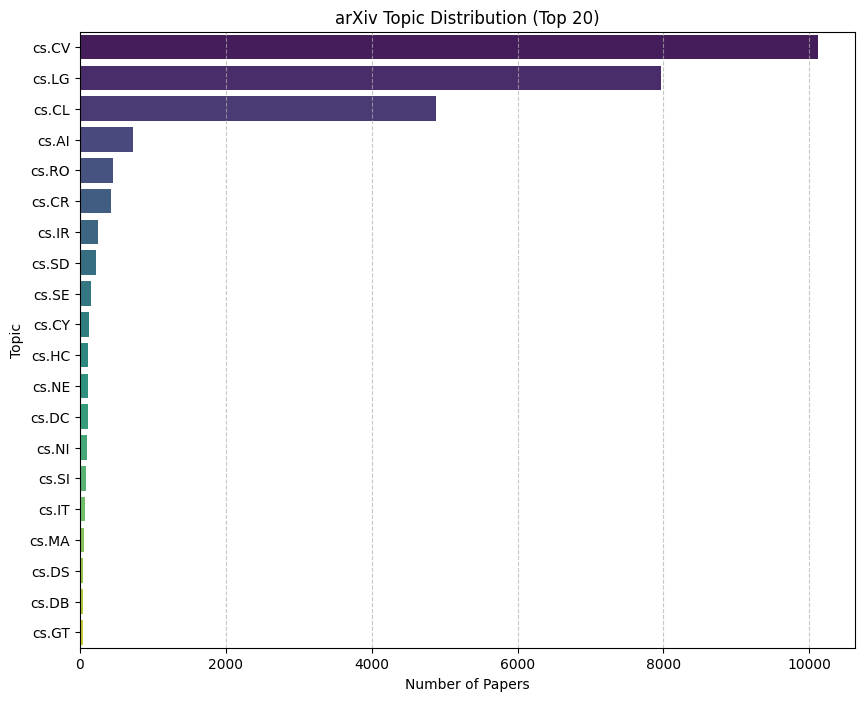

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 上位20カテゴリを抽出
top_topics = df_arxiv['topic'].value_counts().head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_topics.values, y=top_topics.index, palette="viridis")
plt.title("arXiv Topic Distribution (Top 20)")
plt.xlabel("Number of Papers")
plt.ylabel("Topic")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [20]:
import pandas as pd

# arXiv CSカテゴリの定義データ
# コード, 英語正式名称, 日本語名
topic_definitions = [
    {"topic": "cs.AI", "name_en": "Artificial Intelligence", "name_jp": "人工知能"},
    {"topic": "cs.AR", "name_en": "Hardware Architecture", "name_jp": "ハードウェアアーキテクチャ"},
    {"topic": "cs.CC", "name_en": "Computational Complexity", "name_jp": "計算複雑性理論"},
    {"topic": "cs.CE", "name_en": "Computational Engineering, Finance, and Science", "name_jp": "計算工学・金融・科学"},
    {"topic": "cs.CG", "name_en": "Computational Geometry", "name_jp": "計算幾何学"},
    {"topic": "cs.CL", "name_en": "Computation and Language", "name_jp": "計算言語学（自然言語処理）"},
    {"topic": "cs.CR", "name_en": "Cryptography and Security", "name_jp": "暗号とセキュリティ"},
    {"topic": "cs.CV", "name_en": "Computer Vision and Pattern Recognition", "name_jp": "コンピュータビジョンとパターン認識"},
    {"topic": "cs.CY", "name_en": "Computers and Society", "name_jp": "コンピュータと社会"},
    {"topic": "cs.DB", "name_en": "Databases", "name_jp": "データベース"},
    {"topic": "cs.DC", "name_en": "Distributed, Parallel, and Cluster Computing", "name_jp": "分散・並列・クラスタコンピューティング"},
    {"topic": "cs.DL", "name_en": "Digital Libraries", "name_jp": "デジタル図書館"},
    {"topic": "cs.DM", "name_en": "Discrete Mathematics", "name_jp": "離散数学"},
    {"topic": "cs.DS", "name_en": "Data Structures and Algorithms", "name_jp": "データ構造とアルゴリズム"},
    {"topic": "cs.ET", "name_en": "Emerging Technologies", "name_jp": "新興技術"},
    {"topic": "cs.FL", "name_en": "Formal Languages and Automata Theory", "name_jp": "形式言語とオートマトン理論"},
    {"topic": "cs.GL", "name_en": "General Literature", "name_jp": "一般文献"},
    {"topic": "cs.GR", "name_en": "Graphics", "name_jp": "グラフィックス"},
    {"topic": "cs.GT", "name_en": "Computer Science and Game Theory", "name_jp": "コンピュータ科学とゲーム理論"},
    {"topic": "cs.HC", "name_en": "Human-Computer Interaction", "name_jp": "ヒューマンコンピュータインタラクション"},
    {"topic": "cs.IR", "name_en": "Information Retrieval", "name_jp": "情報検索"},
    {"topic": "cs.IT", "name_en": "Information Theory", "name_jp": "情報理論"},
    {"topic": "cs.LG", "name_en": "Machine Learning", "name_jp": "機械学習"},
    {"topic": "cs.LO", "name_en": "Logic in Computer Science", "name_jp": "計算機科学における論理"},
    {"topic": "cs.MA", "name_en": "Multiagent Systems", "name_jp": "マルチエージェントシステム"},
    {"topic": "cs.MM", "name_en": "Multimedia", "name_jp": "マルチメディア"},
    {"topic": "cs.MS", "name_en": "Mathematical Software", "name_jp": "数学ソフトウェア"},
    {"topic": "cs.NA", "name_en": "Numerical Analysis", "name_jp": "数値解析"},
    {"topic": "cs.NE", "name_en": "Neural and Evolutionary Computing", "name_jp": "神経・進化計算"},
    {"topic": "cs.NI", "name_en": "Networking and Internet Architecture", "name_jp": "ネットワークとインターネットアーキテクチャ"},
    {"topic": "cs.OH", "name_en": "Other Computer Science", "name_jp": "その他"},
    {"topic": "cs.OS", "name_en": "Operating Systems", "name_jp": "オペレーティングシステム"},
    {"topic": "cs.PF", "name_en": "Performance", "name_jp": "パフォーマンス"},
    {"topic": "cs.PL", "name_en": "Programming Languages", "name_jp": "プログラミング言語"},
    {"topic": "cs.RO", "name_en": "Robotics", "name_jp": "ロボット工学"},
    {"topic": "cs.SC", "name_en": "Symbolic Computation", "name_jp": "数式処理"},
    {"topic": "cs.SD", "name_en": "Sound", "name_jp": "音響処理"},
    {"topic": "cs.SE", "name_en": "Software Engineering", "name_jp": "ソフトウェア工学"},
    {"topic": "cs.SI", "name_en": "Social and Information Networks", "name_jp": "社会・情報ネットワーク"},
    {"topic": "cs.SY", "name_en": "Systems and Control", "name_jp": "システムと制御"}
]

# DataFrameの作成
df_topics = pd.DataFrame(topic_definitions)

# 確認
df_topics

,topic,name_en,name_jp
0,cs.AI,Artificial Intelligence,人工知能
1,cs.AR,Hardware Architecture,ハードウェアアーキテクチャ
2,cs.CC,Computational Complexity,計算複雑性理論
3,cs.CE,"Computational Engineering, Finance, and Science",計算工学・金融・科学
4,cs.CG,Computational Geometry,計算幾何学
5,cs.CL,Computation and Language,計算言語学（自然言語処理）
6,cs.CR,Cryptography and Security,暗号とセキュリティ
7,cs.CV,Computer Vision and Pattern Recognition,コンピュータビジョンとパターン認識
8,cs.CY,Computers and Society,コンピュータと社会
9,cs.DB,Databases,データベース


In [21]:
import pandas as pd
import numpy as np

# 1. データの読み込み
df_arxiv = pd.read_csv("../dataset/arxiv_cs_Data/arxiv_cs_raw_2020-2026.csv", encoding="utf-8-sig")

# --- A. データ型の確認と修正 ---

# 欠損値（NaN）を空文字に置換（テキスト処理のエラー防止）
text_cols = ['title', 'description', 'authors', 'topic']
for col in text_cols:
    df_arxiv[col] = df_arxiv[col].fillna("").astype(str)

# 日付を datetime型 と 数値型 の両方で使えるようにする
# エラー(変換できない文字)がある場合は NaT にして、その後削除する安全策
df_arxiv['date_dt'] = pd.to_datetime(df_arxiv['date'].astype(str), format='%Y%m%d', errors='coerce')
df_arxiv = df_arxiv.dropna(subset=['date_dt']) # 日付がおかしい行は削除

# --- B. モデルに入力するための「統合テキスト」を作成 ---

# モデルが文脈を理解しやすいフォーマット（プロンプトのような形式）に結合します
# 例: "Title: [タイトル] \n Topic: [トピック] \n Abstract: [要約]"
df_arxiv['input_text'] = (
    "Title: " + df_arxiv['title'] + "\n" +
    "Topic: " + df_arxiv['topic'] + "\n" +
    "Abstract: " + df_arxiv['description']
)

# --- C. 学習用・検証用・テスト用に分割 (時系列スプリット) ---
# 未来の情報をカンニングしないよう、年で区切ります

# 学習用 (Train): 2020年 ~ 2024年 (基礎知識)
train_df = df_arxiv[df_arxiv['year'] <= 2024].copy()

# 検証用 (Val): 2025年 (学習中のチューニング用)
val_df = df_arxiv[df_arxiv['year'] == 2025].copy()

# テスト用 (Test): 2026年 (未知の最新データでの性能評価)
test_df = df_arxiv[df_arxiv['year'] == 2026].copy()

# --- 確認 ---
print("=== データセット構成 ===")
print(f"Train (2020-2024): {len(train_df)} 件")
print(f"Val   (2025)     : {len(val_df)} 件")
print(f"Test  (2026)     : {len(test_df)} 件")
print("\n=== 入力テキスト例 ===")
print(train_df['input_text'].iloc[0][:200] + "...") # 最初の200文字だけ表示

=== データセット構成 ===
Train (2020-2024): 18798 件
Val   (2025)     : 3896 件
Test  (2026)     : 3664 件

=== 入力テキスト例 ===
Title: Bosonic Random Walk Networks for Graph Learning
Topic: cs.LG
Abstract: The development of Graph Neural Networks (GNNs) has led to great progress in machine learning on graph-structured data. Th...
